# Principal Component Analysis (PCA)

Modern machine learning datasets routinely contain dozens, hundreds, or even thousands of features. Working in such high-dimensional spaces introduces a cascade of problems: models overfit more easily, distances between points become less meaningful, training becomes computationally expensive, and visualization is impossible. This phenomenon is collectively known as the **curse of dimensionality**.

**Principal Component Analysis (PCA)** is the most widely used technique for addressing this challenge. It finds a lower-dimensional linear subspace that captures the **directions of maximum variance** in the data, allowing practitioners to reduce the number of features while preserving as much information as possible. Critically, PCA is **unsupervised** — it requires no labels and operates purely on the geometric structure of the input.

In this notebook, we derive the mathematical foundations of PCA, implement it step by step, benchmark the `PCA` class from `ifri_mini_ml_lib` against `scikit-learn`, and discuss its real-world applications and limitations.

## 1. Key Concepts

### 1.1 Problem Formulation

Let $X \in \mathbb{R}^{N \times D}$ be a dataset of $N$ samples and $D$ features. PCA seeks a linear projection matrix $W \in \mathbb{R}^{D \times K}$ with $K \ll D$ such that the projected data:

$$Z = \tilde{X} W \in \mathbb{R}^{N \times K}$$

maximizes the variance of the projections. The columns $\{w_1, w_2, \dots, w_K\}$ of $W$ are called **principal components** and satisfy:
- $\|w_k\|_2 = 1$ (unit norm)
- $w_i^\top w_j = 0$ for $i \neq j$ (mutual orthogonality)
- $\text{Var}(\tilde{X} w_1) \geq \text{Var}(\tilde{X} w_2) \geq \dots \geq \text{Var}(\tilde{X} w_K)$ (ordered by explained variance)

### 1.2 Why Centering is Required

PCA measures variance relative to the **origin**. If the data is not centered, the first principal component will point toward the mean of the data rather than the direction of maximum spread. Centering ensures that the covariance matrix — and therefore the principal components — reflect the true structure of the data:

$$\tilde{X} = X - \mu, \quad \mu_j = \frac{1}{N} \sum_{i=1}^{N} x_{ij}$$

### 1.3 Explained Variance

Each principal component $w_k$ is associated with an **eigenvalue** $\lambda_k$ that quantifies how much variance it explains. The proportion of total variance explained by the top $K$ components is:

$$\text{Explained Variance Ratio}(K) = \frac{\sum_{k=1}^{K} \lambda_k}{\sum_{j=1}^{D} \lambda_j}$$

A common heuristic is to choose $K$ such that this ratio exceeds **95%**, or to identify the *elbow point* in the scree plot (cumulative explained variance curve).

## 2. The 5 Steps of PCA

### Step 1 — Centering

Subtract the mean of each feature column to center the data around the origin:

$$\tilde{X} = X - \mu, \quad \mu \in \mathbb{R}^{D}$$

After centering, $\frac{1}{N} \sum_{i=1}^{N} \tilde{x}_{ij} = 0$ for every feature $j$. This step is mandatory — skipping it biases all subsequent computations.

### Step 2 — Covariance Matrix

Compute the $D \times D$ **empirical covariance matrix** of the centered data:

$$\Sigma = \frac{1}{N-1} \tilde{X}^\top \tilde{X} \in \mathbb{R}^{D \times D}$$

Each entry $\Sigma_{jl}$ measures the linear co-variation between features $j$ and $l$:
- $\Sigma_{jj}$ is the **variance** of feature $j$
- $\Sigma_{jl}$ for $j \neq l$ is the **covariance** between features $j$ and $l$

The matrix $\Sigma$ is **symmetric** ($\Sigma = \Sigma^\top$) and **positive semi-definite** ($v^\top \Sigma v \geq 0$ for all $v$), which guarantees real, non-negative eigenvalues.

### Step 3 — Eigendecomposition

Decompose the covariance matrix into its **eigenvalues** and **eigenvectors**:

$$\Sigma = V \Lambda V^\top$$

where $\Lambda = \text{diag}(\lambda_1, \lambda_2, \dots, \lambda_D)$ contains the eigenvalues and $V = [v_1 \mid v_2 \mid \dots \mid v_D]$ contains the corresponding orthonormal eigenvectors.

Each eigenvector $v_k$ satisfies:

$$\Sigma v_k = \lambda_k v_k$$

Intuitively, $v_k$ defines a **direction** in feature space and $\lambda_k$ measures the **spread** of the data along that direction. The eigenvector with the largest eigenvalue is the first principal component — the single direction that captures the most variance.

### Step 4 — Select Top-$K$ Eigenvectors

Sort eigenvectors by their eigenvalues in **descending order** and retain only the top $K$:

$$W = [v_{(1)}, v_{(2)}, \dots, v_{(K)}] \in \mathbb{R}^{D \times K}, \quad \lambda_{(1)} \geq \lambda_{(2)} \geq \dots \geq \lambda_{(K)}$$

This step is the actual **dimensionality reduction**: we discard the $D - K$ directions of least variance, keeping only the $K$ most informative ones.

**Choosing $K$**: Plot the cumulative explained variance ratio and select $K$ at the elbow — the point beyond which adding more components yields diminishing returns in explained variance.

### Step 5 — Project

Project the centered data onto the $K$-dimensional subspace spanned by the selected eigenvectors:

$$Z = \tilde{X} W \in \mathbb{R}^{N \times K}$$

Each row $z_i = \tilde{x}_i W$ is the **$K$-dimensional representation** of sample $i$ in the new principal component space. The columns of $Z$ are uncorrelated by construction, since the eigenvectors are orthogonal.

## 3. Pseudo-algorithm

**`fit(X)`** — *Learn principal components from training data*

1. $X \in \mathbb{R}^{N \times D} \leftarrow$ input data matrix, $K \leftarrow$ number of components
2. $\mu \leftarrow \text{mean}(X, \text{axis}=0)$ &nbsp;&nbsp; *(compute feature means)*
3. $\tilde{X} \leftarrow X - \mu$ &nbsp;&nbsp; *(Step 1: Center)*
4. $\Sigma \leftarrow \text{cov}(\tilde{X})$ &nbsp;&nbsp; *(Step 2: Covariance matrix)*
5. $\lambda, V \leftarrow \text{eig}(\Sigma)$ &nbsp;&nbsp; *(Step 3: Eigendecomposition)*
6. $\mathcal{I} \leftarrow \text{argsort}(\lambda)[::-1]$ &nbsp;&nbsp; *(sort indices by descending eigenvalue)*
7. $W \leftarrow V[:, \mathcal{I}[:K]]$ &nbsp;&nbsp; *(Step 4: Select top-K eigenvectors)*
8. Store $\mu$ and $W$ in `self`

---

**`transform(X)`** — *Project new data onto learned components*

1. $\tilde{X} \leftarrow X - \mu$ &nbsp;&nbsp; *(center using stored training mean)*
2. $Z \leftarrow \tilde{X} \cdot W$ &nbsp;&nbsp; *(Step 5: Project)*
3. **return** $Z \in \mathbb{R}^{N \times K}$

---

> **Key design principle**: The mean $\mu$ and projection matrix $W$ are computed **once** during `fit()` on the training data. When `transform()` is called on test data, it applies the **same** $\mu$ and $W$ — never recomputes them. This is essential to avoid data leakage and ensure consistent dimensionality reduction across train/test splits.

## 4. Implementation & Benchmarking

We benchmark the `PCA` class from `ifri_mini_ml_lib` against `sklearn.decomposition.PCA` on the **Iris dataset** (150 samples, 4 features), reducing it to $K=2$ principal components. We compare execution time, output shape, and the visual quality of the 2D projection.

### 4.1 Dataset Loading

In [8]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# ── Load Iris dataset ─────────────────────────────────────────
iris        = load_iris()
X           = pd.DataFrame(iris.data, columns=iris.feature_names)
y           = pd.Series(iris.target)
target_names = iris.target_names

print(f"Dataset shape : {X.shape}  ({X.shape[0]} samples, {X.shape[1]} features)")
print(f"Classes       : {list(target_names)}")
X.head()

Dataset shape : (150, 4)  (150 samples, 4 features)
Classes       : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 4.2 With Scikit-learn

In [9]:
from sklearn.decomposition import PCA as SklearnPCA

# ── Fit and transform with sklearn PCA ───────────────────────
start_1          = time.perf_counter()
pca_sklearn      = SklearnPCA(n_components=2)
X_reduced_sklearn = pca_sklearn.fit_transform(X)
end_1            = time.perf_counter()

print(f"sklearn PCA — output shape   : {X_reduced_sklearn.shape}")
print(f"sklearn PCA — execution time : {(end_1 - start_1)*1000:.4f} ms")
print(f"sklearn PCA — explained var  : {pca_sklearn.explained_variance_ratio_.round(4)}")

sklearn PCA — output shape   : (150, 2)
sklearn PCA — execution time : 3.2844 ms
sklearn PCA — explained var  : [0.9246 0.0531]


### 4.3 With ifri-mini-ml-lib

In [ ]:
from ifri_mini_ml_lib.preprocessing.dimensionality_reduction import PCA

# ── Fit and transform with ifri_mini_ml_lib PCA ───────────────
start_2         = time.perf_counter()
pca_ifri        = PCA(n_component=2)
X_reduced_ifri  = pca_ifri.fit_transform(X)
end_2           = time.perf_counter()

print(f"ifri PCA — output shape   : {X_reduced_ifri.shape}")
print(f"ifri PCA — execution time : {(end_2 - start_2)*1000:.4f} ms")

ifri PCA — output shape   : (150, 2)
ifri PCA — execution time : 1.9955 ms


### 4.4 Results

In [11]:
# ── Comparison table ──────────────────────────────────────────
t_sklearn = (end_1 - start_1) * 1000
t_ifri    = (end_2 - start_2) * 1000

results = pd.DataFrame({
    'Metric'          : ['Output Shape', 'Execution Time (ms)', 'Speedup (x)'],
    'scikit-learn'    : [
        str(X_reduced_sklearn.shape),
        round(t_sklearn, 4),
        '1.00 (baseline)'
    ],
    'ifri-mini-ml-lib': [
        str(X_reduced_ifri.shape),
        round(t_ifri, 4),
        round(t_sklearn / t_ifri, 2)
    ]
})

results

,Metric,scikit-learn,ifri-mini-ml-lib
0,Output Shape,"(150, 2)","(150, 2)"
1,Execution Time (ms),3.2844,2.1955
2,Speedup (x),1.00 (baseline),1.5


**How to read this table:**
- **Output Shape** confirms both implementations reduce the data from $(150, 4)$ to $(150, 2)$ as expected.
- **Execution Time** measures the wall-clock time for a single `fit_transform()` call in milliseconds.
- **Speedup (x)** = `sklearn_time / ifri_time`. A value greater than 1 means `ifri_mini_ml_lib` is faster.
- Note that timing differences on small datasets like Iris can be dominated by Python overhead rather than algorithmic complexity. Results become more meaningful on larger datasets.

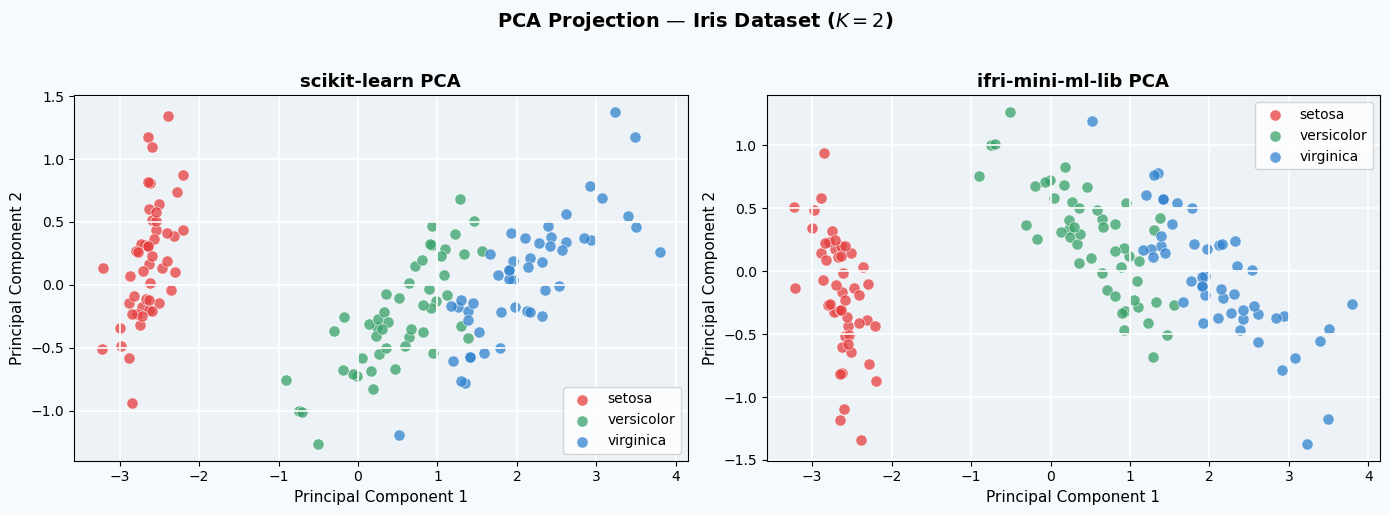

In [12]:
# ── Side-by-side 2D projection plots ─────────────────────────
colors       = ['#E53E3E', '#38A169', '#3182CE']
fig, axes    = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F7FAFC')

for ax, X_red, title in zip(
    axes,
    [X_reduced_sklearn, X_reduced_ifri],
    ['scikit-learn PCA', 'ifri-mini-ml-lib PCA']
):
    ax.set_facecolor('#EDF2F7')
    for i, (name, color) in enumerate(zip(target_names, colors)):
        mask = (y == i)
        ax.scatter(
            X_red[mask, 0], X_red[mask, 1],
            label=name, color=color,
            alpha=0.75, edgecolors='white', linewidths=0.5, s=65
        )
    ax.set_xlabel('Principal Component 1', fontsize=11)
    ax.set_ylabel('Principal Component 2', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.8)
    ax.grid(True, color='white', linewidth=1.2)

plt.suptitle(
    'PCA Projection — Iris Dataset ($K=2$)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

**How to read this chart:**
- Each point represents one Iris sample projected onto the first two principal components (PC1 and PC2).
- **Colors** denote the three species: *Setosa* (red), *Versicolor* (green), *Virginica* (blue).
- **PC1** (horizontal axis) explains the most variance — notice that Setosa is clearly separated from the other two classes along this axis alone.
- **PC2** (vertical axis) provides additional separation between Versicolor and Virginica.
- The two plots should be **mirror images** of each other: PCA is unique up to sign flips of the eigenvectors, so the axes may be reflected between implementations — this is mathematically correct and expected.
- If both projections show the same cluster structure, the two implementations are equivalent.

### 4.5 Cumulative Explained Variance

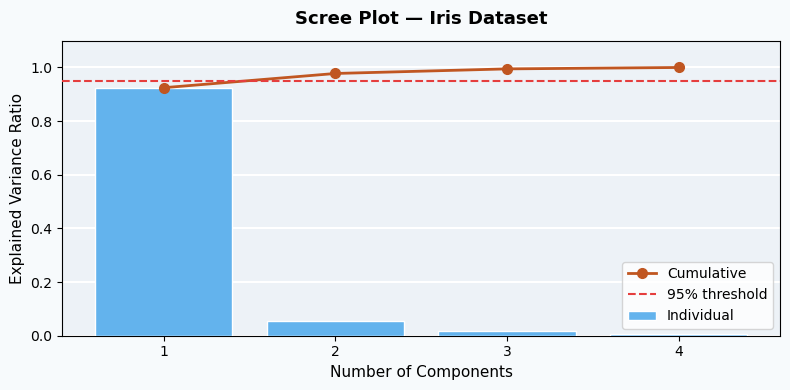

Individual explained variance ratio:
  PC1: 0.9246 (92.46%)
  PC2: 0.0531 (5.31%)
  PC3: 0.0171 (1.71%)
  PC4: 0.0052 (0.52%)

Top 2 components explain: 97.77% of total variance


In [13]:
# ── Scree plot using sklearn eigenvalues as reference ─────────
# Run full PCA (all components) to get the complete variance spectrum
pca_full   = SklearnPCA(n_components=None)
pca_full.fit(X)

ev_ratio   = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ev_ratio)
components = np.arange(1, len(ev_ratio) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#EDF2F7')
ax.yaxis.grid(True, color='white', linewidth=1.5, zorder=0)

ax.bar(components, ev_ratio, color='#63B3ED', edgecolor='white',
       label='Individual', zorder=3)
ax.plot(components, cumulative, 'o-', color='#C05621',
        linewidth=2, markersize=7, label='Cumulative', zorder=4)

# Mark the 95% threshold
ax.axhline(0.95, color='#E53E3E', linestyle='--', linewidth=1.5,
           label='95% threshold', zorder=5)

ax.set_xlabel('Number of Components', fontsize=11)
ax.set_ylabel('Explained Variance Ratio', fontsize=11)
ax.set_title('Scree Plot — Iris Dataset', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(components)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Individual explained variance ratio:")
for k, r in enumerate(ev_ratio, 1):
    print(f"  PC{k}: {r:.4f} ({r*100:.2f}%)")
print(f"\nTop 2 components explain: {cumulative[1]*100:.2f}% of total variance")

**How to read this chart:**
- **Blue bars** show the individual variance explained by each principal component.
- **Orange line** shows the cumulative variance explained as more components are added.
- **Red dashed line** marks the 95% threshold — a common criterion for choosing $K$.
- For the Iris dataset, the first 2 components already explain over 95% of the total variance, confirming that $K=2$ is a well-justified choice and that the original 4 features are highly correlated.

## 5. Real-life Applications

PCA is one of the most versatile tools in data science, applied across domains wherever high-dimensional data must be compressed, visualized, or decorrelated:

1. **Image Compression & Facial Recognition**: Pixel matrices are high-dimensional vectors ($D$ = number of pixels). PCA identifies the *eigenfaces* — the principal components of a face dataset — and represents each image as a linear combination of a small number of eigenfaces. This was the basis of early face recognition systems (Turk & Pentland, 1991) and remains relevant for compression pipelines.

2. **Genomics & Population Genetics**: Gene expression datasets typically contain $D > 10{,}000$ features (genes) and only a few hundred samples. PCA is used to identify the main axes of biological variation, detect batch effects, and visualize population structure in genome-wide association studies (GWAS). The first two principal components often correspond to geographic ancestry.

3. **Finance & Risk Management**: In portfolio analysis, PCA decomposes the covariance matrix of asset returns to extract **latent risk factors** (e.g., market factor, sector factor). This allows risk managers to understand the independent sources of portfolio variance and construct hedging strategies.

4. **Natural Language Processing (Pre-deep-learning)**: **Latent Semantic Analysis (LSA)** applies PCA (via Singular Value Decomposition) to TF-IDF matrices, mapping documents and words to a shared low-dimensional semantic space. This enables document similarity, clustering, and topic inference without labeled data.

## 6. Limitations and Challenges

Despite its widespread success, PCA has fundamental limitations that must be understood before applying it in practice.

### 6.1 Linearity

PCA can only capture **linear** structure in the data. If the meaningful low-dimensional manifold is non-linear (e.g., a Swiss roll, a circle, or a helix embedded in 3D), PCA will fail to "unroll" it and produce a poor representation.

- **Symptom**: The explained variance curve is flat — many components are needed to reach 95%, even though the intrinsic dimensionality is low.
- **Alternatives**: Kernel PCA (non-linear feature maps), t-SNE, UMAP (manifold learning).

---

### 6.2 Sensitivity to Feature Scale

PCA is based on variance. If features are measured in different units (e.g., one feature in meters and another in grams), the feature with the largest scale will dominate the covariance matrix and therefore the first principal component — regardless of its actual importance.

Formally, if feature $j$ has scale $s_j$, its contribution to $\Sigma_{jj}$ scales as $s_j^2$, making it $s_j^2 / s_l^2$ times more influential than feature $l$.

- **Mitigation**: **Standardize** the data (subtract mean, divide by standard deviation) before applying PCA, so all features have unit variance:

$$x_{ij}^{\text{std}} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

---

### 6.3 Loss of Interpretability

Each principal component is a **linear combination of all original features**, not a single feature. It is therefore impossible to assign a simple domain meaning to a principal component (e.g., "PC1 is temperature"). This lack of interpretability can be a significant drawback in regulated industries (healthcare, finance) where model transparency is required.

- **Alternatives**: Sparse PCA (forces most loadings to zero), Independent Component Analysis (ICA).

---

### 6.4 Information Loss is Irreversible

Projecting from $D$ to $K < D$ dimensions discards the variance in the remaining $D - K$ components. While reconstruction is possible:

$$\hat{X} = Z W^\top + \mu$$

the reconstruction error $\|X - \hat{X}\|_F^2 = \sum_{k=K+1}^{D} \lambda_k$ is non-zero whenever $K < D$. Discarded information cannot be recovered.

## 7. References

- Jolliffe, I. T. (2002). *Principal Component Analysis*, 2nd edition. Springer Series in Statistics.
- Turk, M., & Pentland, A. (1991). *Eigenfaces for Recognition*. Journal of Cognitive Neuroscience, 3(1), 71-86.
- Raschka, S. (2015). *Principal Component Analysis in 3 Simple Steps*, https://sebastianraschka.com/Articles/2015_pca_in_3_steps.html
- Decomposition — Scikit-learn Documentation, https://scikit-learn.org/stable/modules/decomposition.html#pca
- Van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579-2605.